# Clasificación de cáncer de mama — Regresión logística

**Maestría en Inteligencia Artificial Aplicada (MNA)** · Tecnológico de Monterrey
Curso TC5053 — Ciencia y analítica de datos · Semana 9: Regresión logística

**Autor:** Ricardo Martín Galván Páez

---

## Resumen

Este notebook analiza el conjunto de datos `breast_cancer.csv` (*Breast Cancer Wisconsin – Diagnostic*, repositorio UCI Machine Learning) y construye modelos de **regresión logística** para clasificar un tumor como maligno (`M`) o benigno (`B`). La **variable objetivo** es `diagnosis`.

| Paso | Sección | Técnica |
|---|---|---|
| 1 | Carga e inspección | `info()`, faltantes, duplicados, estadísticas con asimetría y curtosis |
| 2 | EDA | Distribución del objetivo, *pairplot*, histogramas apilados |
| 3 | Correlación y selección de variables | Pares con \|r\| > 0.9, correlación con el objetivo, mapa de calor |
| 4 | Partición y evaluación | 80:20 (`random_state=1`), función `evaluate_model` |
| 5 | Modelo 1 | Eliminación de variables correlacionadas, sin escalar (*Correlation_Clean*) |
| 6 | Modelo 2 | `StandardScaler` + PCA (≥ 90 % de varianza) (*Standard_PCA*) |
| 7 | Modelo 3 | Yeo-Johnson (*Correlation_Yeo*) y control solo con `StandardScaler` |
| 8 | Coeficientes | Los 10 predictores más influyentes |
| 9 | Evaluación del mejor modelo | Matriz de confusión y curva ROC |
| 10 | Probabilidades y umbral | Distribución de probabilidades, análisis de umbrales |

**Ejecución:** el notebook corre en Google Colab (el CSV se lee desde Google Drive) o en local (colocar el CSV en `data/breast_cancer.csv`).

> **Aviso:** proyecto con fines educativos. El modelo no es una herramienta de diagnóstico clínico.

## Descripción del conjunto de datos

Los datos describen tumores mamarios a partir de imágenes digitalizadas de una punción con aguja fina (PAAF). Cada característica se calcula sobre los **núcleos celulares** visibles en la imagen. El objetivo es determinar si un tumor es maligno (`M`) o benigno (`B`). Hay 569 registros, 30 variables numéricas, `diagnosis` e `id`.

Cada una de las 10 características se presenta en tres medidas:

| Sufijo | Significado |
|---|---|
| `_mean` | Media de la característica sobre todos los núcleos de la imagen |
| `_se` | Error estándar de la característica |
| `_worst` | Media de los tres valores más grandes (el «peor» valor) |

| Característica | Descripción |
|---|---|
| `radius` | Radio: distancia media del centro a los puntos del contorno |
| `texture` | Textura: desviación estándar de los valores de gris |
| `perimeter` | Perímetro |
| `area` | Área |
| `smoothness` | Suavidad: variación local en la longitud de los radios |
| `compactness` | Compacidad: perímetro² / área − 1 |
| `concavity` | Concavidad: severidad de las porciones cóncavas del contorno |
| `concave points` | Puntos cóncavos: número de porciones cóncavas del contorno |
| `symmetry` | Simetría |
| `fractal_dimension` | Dimensión fractal: «aproximación de la línea costera» − 1 (complejidad del contorno) |
| `diagnosis` | Benigno (`B`) o maligno (`M`). **Variable objetivo** |

> **Nota.** Los mismos datos se distribuyen con scikit-learn (`sklearn.datasets.load_breast_cancer`), con nombres de columna distintos.

---

## 0. Configuración inicial

In [1]:
# Importar las bibliotecas necesarias
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler

In [2]:
# Ubicación de los datos: Google Drive en Colab, ./data/ en ejecución local
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = "/content/drive/MyDrive/Posgrado/1er trimestre/TC5053.10_Ciencia y analítica de datos/Colab/Actividad 9 | Regresión logística"
except ImportError:
    DATA_DIR = "data"  # ejecución local: colocar breast_cancer.csv en ./data/

Mounted at /content/drive


---

## 1. Carga e inspección inicial

**Objetivos**
- Cargar todos los registros en un dataframe (`cancer_df`) y usar la columna `id` como índice.
- Resumir los tipos de datos con `info()`: ¿cuántas columnas son numéricas y cuántas de texto?
- Verificar valores faltantes y registros duplicados.
- Obtener estadísticas descriptivas: numéricas (con asimetría y curtosis) y categóricas.

In [3]:
cancer_df = pd.read_csv(os.path.join(DATA_DIR, 'breast_cancer.csv'))
cancer_df.set_index('id', inplace=True)
cancer_df.info()
print('='*50)
num_cols = cancer_df.select_dtypes(include='number').columns
cat_cols = cancer_df.select_dtypes(exclude='number').columns

print(f'Columnas numéricas: {len(num_cols)}')
print(f'Columnas categóricas: {len(cat_cols)}')
print('='*50)

# Valores faltantes
print(f'Valores faltantes: \n{cancer_df.isnull().sum()}')
print('='*50)

# Valores duplicados
print(f'Valores duplicados: {cancer_df.duplicated().sum()}')
print('='*50)

# Estadísticas descriptivas
print('Estadísticas descriptivas numéricas:')
describe_df = cancer_df[num_cols].describe().T
describe_df['asimetria'] = cancer_df[num_cols].skew()
describe_df['curtosis'] = cancer_df[num_cols].kurtosis()
display(describe_df)
print('='*50)
print('Estadísticas descriptivas categóricas:')
display(cancer_df[cat_cols].describe())

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                 

,count,mean,std,min,25%,50%,75%,max,asimetria,curtosis
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000,0.942380,0.845522
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000,0.650450,0.758319
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000,0.990650,0.972214
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000,1.645732,3.652303
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340,0.456324,0.855975
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540,1.190123,1.650130
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680,1.401180,1.998638
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120,1.171180,1.066556
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400,0.725609,1.287933
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744,1.304489,3.005892


Estadísticas descriptivas categóricas:


,diagnosis
count,569
unique,2
top,B
freq,357


**Resultado.** El dataframe tiene 569 registros, 30 columnas numéricas y 1 de texto (`diagnosis`). No hay valores faltantes ni registros duplicados, por lo que no se requiere limpieza. Varias variables de tamaño y de error estándar tienen asimetría fuerte (p. ej. `area_se` 5.4, `concavity_se` 5.1), lo que motiva la transformación de la Sección 7.

---

## 2. Análisis exploratorio

**Objetivos**
- Calcular y graficar la distribución porcentual de `diagnosis`. ¿Por qué importa en clasificación?
- Generar un *pairplot* de las variables de tamaño `_mean` (`radius_mean`, `perimeter_mean`, `area_mean`, `texture_mean`), coloreado por `diagnosis`.
- Crear histogramas apilados de las variables morfológicas `_mean`, coloreados por `diagnosis`, para ver cuáles discriminan mejor.

### 2.1 Distribución de la variable objetivo

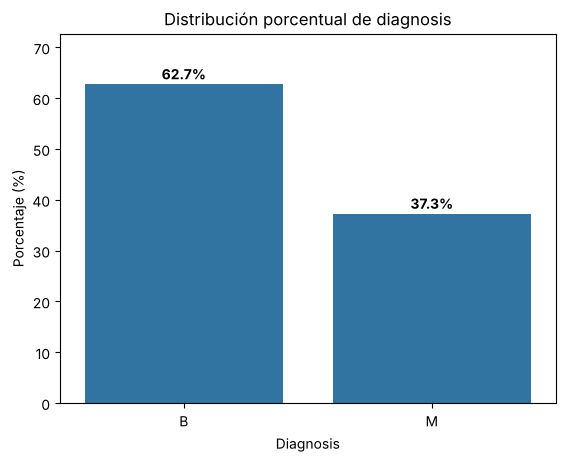

In [4]:
# Distribución de la variable objetivo (%)
dist = cancer_df['diagnosis'].value_counts(normalize=True) * 100

ax = sns.barplot(x=dist.index, y=dist.values)
# Agregar porcentaje encima de cada barra
for i, v in enumerate(dist.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.title('Distribución porcentual de diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Porcentaje (%)')
plt.ylim(0, max(dist.values) + 10)
plt.show()

**Resultado.** 62.7 % de los tumores son benignos (357) y 37.3 % malignos (212): un desbalance moderado. Importa porque un modelo que predijera siempre «benigno» alcanzaría 62.7 % de *accuracy* sin aprender nada y con **0 % de recall** sobre los malignos. Por eso la *accuracy* se interpreta siempre frente a esa línea base y se complementa con recall y precisión.

### 2.2 Variables de tamaño: *pairplot*

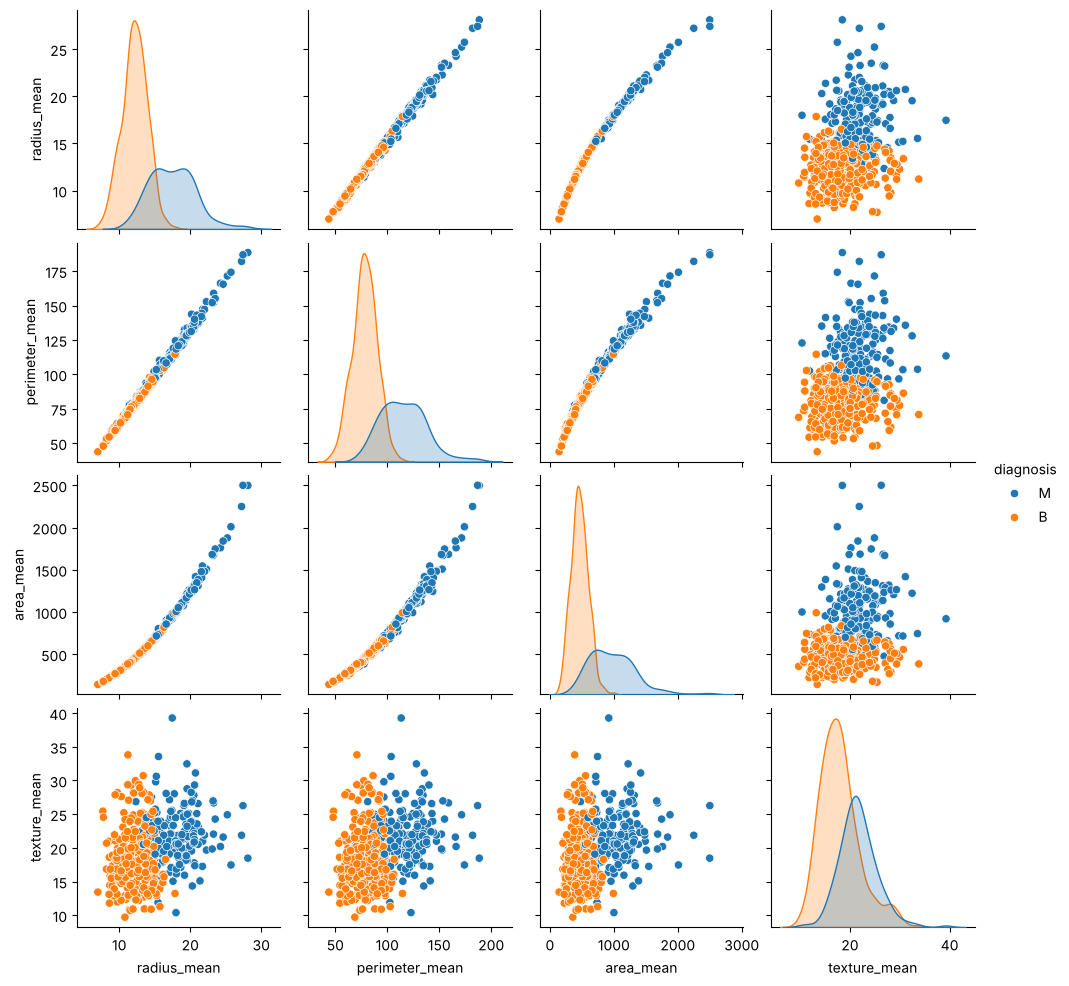

In [5]:
# Pairplot de las variables físicas _mean
sns.pairplot(cancer_df[['radius_mean', 'perimeter_mean', 'area_mean', 'texture_mean', 'diagnosis']], hue='diagnosis')
plt.show()

**Resultado.**
- `radius_mean`, `perimeter_mean` y `area_mean` están casi perfectamente correlacionadas (r ≈ 0.99): son funciones geométricas del mismo tamaño (perímetro = 2πr, área = πr²). La relación del área con las otras dos es ligeramente curva, no estrictamente lineal. Conservar las tres aporta información redundante.
- Los tumores malignos se concentran en valores más altos de tamaño, aunque con cierto traslape con los benignos.
- `texture_mean` también separa las clases, con más traslape que las variables de tamaño, y está poco correlacionada con ellas: aporta información complementaria.

### 2.3 Variables morfológicas: histogramas apilados

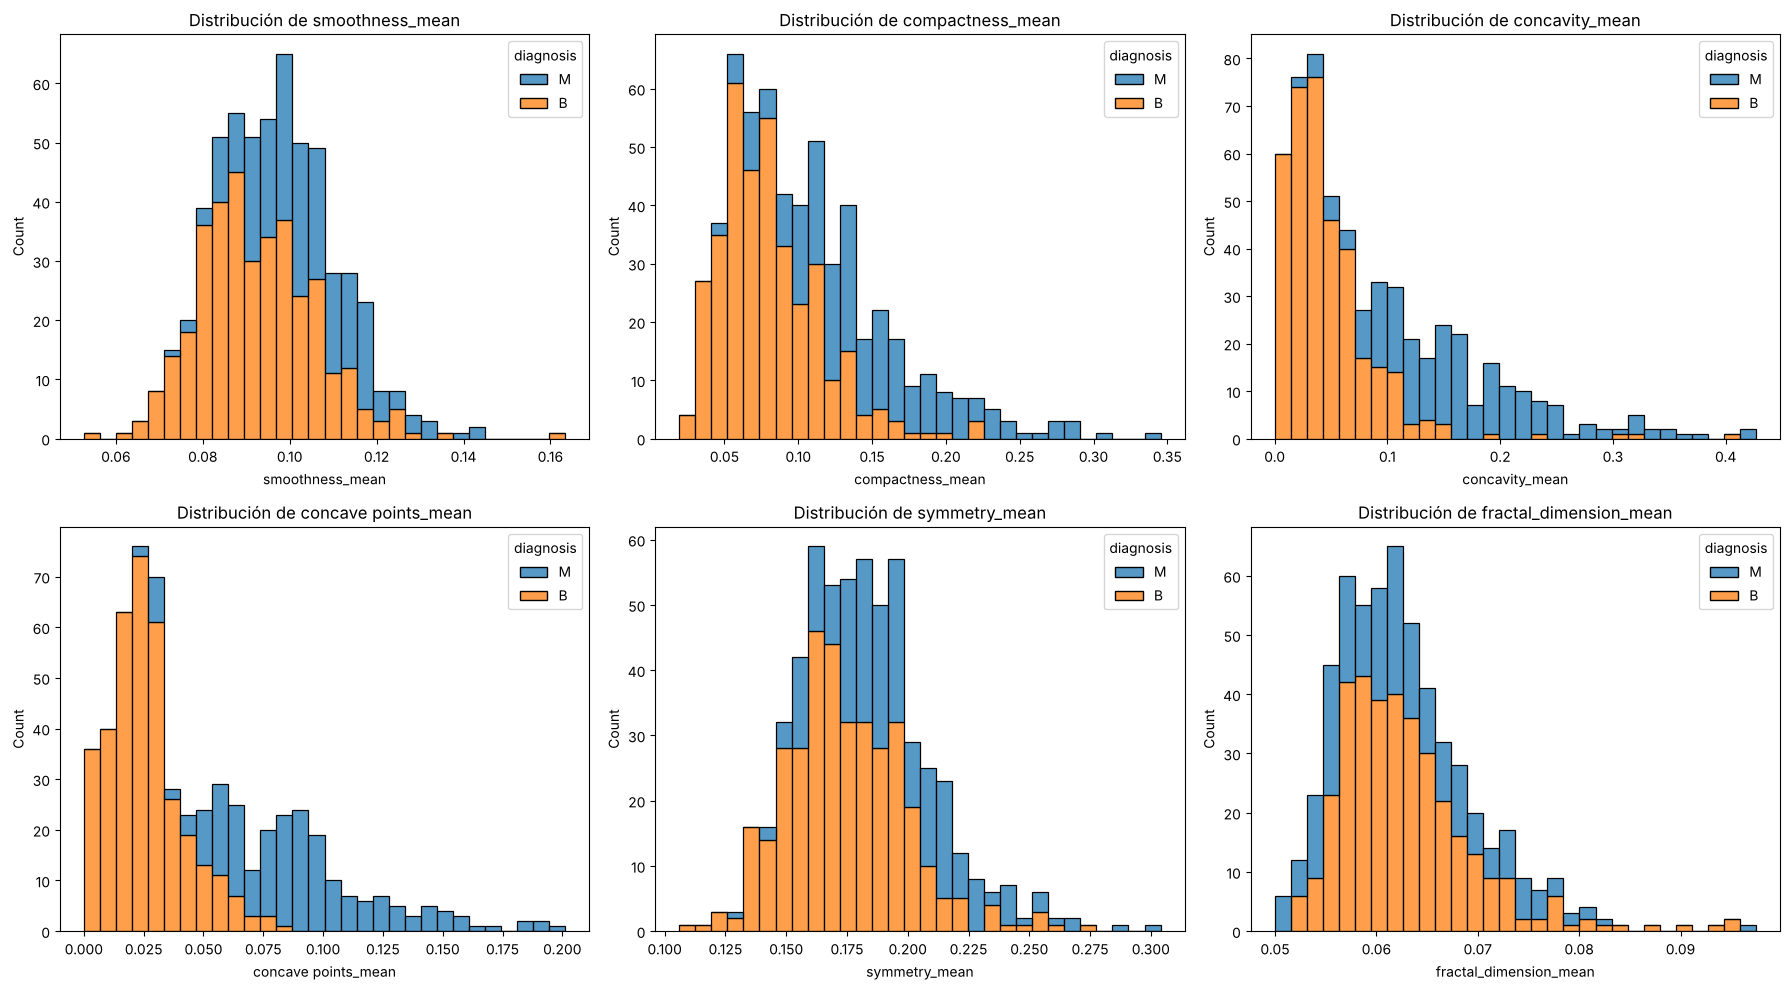

In [6]:
morfologicas = ['smoothness_mean', 'compactness_mean', 'concavity_mean',
                'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(morfologicas):
    sns.histplot(data=cancer_df, x=col, hue='diagnosis', multiple='stack',
                 bins=30, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

**Resultado.** `concave points_mean` y `concavity_mean` son las que mejor discriminan: en valores medios y altos casi solo hay tumores malignos, mientras que en valores bajos ambas clases se traslapan. `concave points_mean` es la más limpia (máximo benigno ≈ 0.085 frente a máximo maligno ≈ 0.20); `concavity_mean` tiene algunos benignos atípicos en valores altos. `compactness_mean` discrimina de forma moderada; `smoothness_mean`, `symmetry_mean` y `fractal_dimension_mean` se traslapan en gran medida y discriminan poco por sí solas.

---

## 3. Correlación y selección de variables

**Objetivos**
- Crear una copia del dataframe (`cancer_copy`) para el análisis de correlación.
- Identificar los pares con correlación superior a 0.9. La alta correlación entre `_mean` y `_worst` es esperable (miden la misma característica), por lo que se eliminan las columnas `_worst`.
- Repetir la búsqueda. Entre `radius`, `perimeter` y `area` (y otros grupos), conservar una variable por grupo y justificar la elección.
- Dibujar el mapa de calor para ver qué correlaciones relevantes persisten.

In [7]:
cancer_copy = cancer_df.copy()

In [8]:
# Pares con correlación mayor a 0.9
corr_matrix = cancer_copy.corr(numeric_only=True)
corr_altas = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            corr_altas.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
corr_altas_df = pd.DataFrame(corr_altas, columns=['Variable 1', 'Variable 2', 'Correlacion']).sort_values(by='Correlacion', ascending=False)
display(corr_altas_df)

,Variable 1,Variable 2,Correlacion
0,radius_mean,perimeter_mean,0.997855
18,radius_worst,perimeter_worst,0.993708
1,radius_mean,area_mean,0.987357
6,perimeter_mean,area_mean,0.986507
19,radius_worst,area_worst,0.984015
20,perimeter_worst,area_worst,0.977578
15,radius_se,perimeter_se,0.972794
8,perimeter_mean,perimeter_worst,0.970387
2,radius_mean,radius_worst,0.969539
7,perimeter_mean,radius_worst,0.969476


In [9]:
# Eliminar las columnas _worst
worst_cols = [col for col in cancer_copy.columns if '_worst' in col]
cancer_copy.drop(columns=worst_cols, inplace=True)

# Pares con correlación mayor a 0.9
corr_matrix = cancer_copy.corr(numeric_only=True)
corr_altas = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            corr_altas.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
corr_altas_df = pd.DataFrame(corr_altas, columns=['Variable 1', 'Variable 2', 'Correlacion']).sort_values(by='Correlacion', ascending=False)
display(corr_altas_df)

,Variable 1,Variable 2,Correlacion
0,radius_mean,perimeter_mean,0.997855
1,radius_mean,area_mean,0.987357
2,perimeter_mean,area_mean,0.986507
4,radius_se,perimeter_se,0.972794
5,radius_se,area_se,0.951830
6,perimeter_se,area_se,0.937655
3,concavity_mean,concave points_mean,0.921391


**Criterio de selección.** Dentro de cada grupo de variables altamente correlacionadas se conserva la que tiene mayor correlación individual con el objetivo:

- **Grupo `_mean` de tamaño:** `perimeter_mean` (0.743) frente a `radius_mean` (0.730) y `area_mean` (0.709).
- **Grupo `_se` de tamaño:** `radius_se` (0.567) frente a `perimeter_se` (0.556) y `area_se` (0.548).
- **Concavidad:** `concave points_mean` (0.777) frente a `concavity_mean` (0.696).

In [10]:
# Correlación individual con el target
diagnosis_num = cancer_df['diagnosis'].map({'M': 1, 'B': 0})
print(cancer_df[['radius_mean', 'perimeter_mean', 'area_mean']].corrwith(diagnosis_num))
print(cancer_df[['radius_se', 'perimeter_se', 'area_se']].corrwith(diagnosis_num))
print(cancer_df[['concavity_mean', 'concave points_mean']].corrwith(diagnosis_num))

radius_mean       0.730029
perimeter_mean    0.742636
area_mean         0.708984
dtype: float64
radius_se       0.567134
perimeter_se    0.556141
area_se         0.548236
dtype: float64
concavity_mean         0.696360
concave points_mean    0.776614
dtype: float64


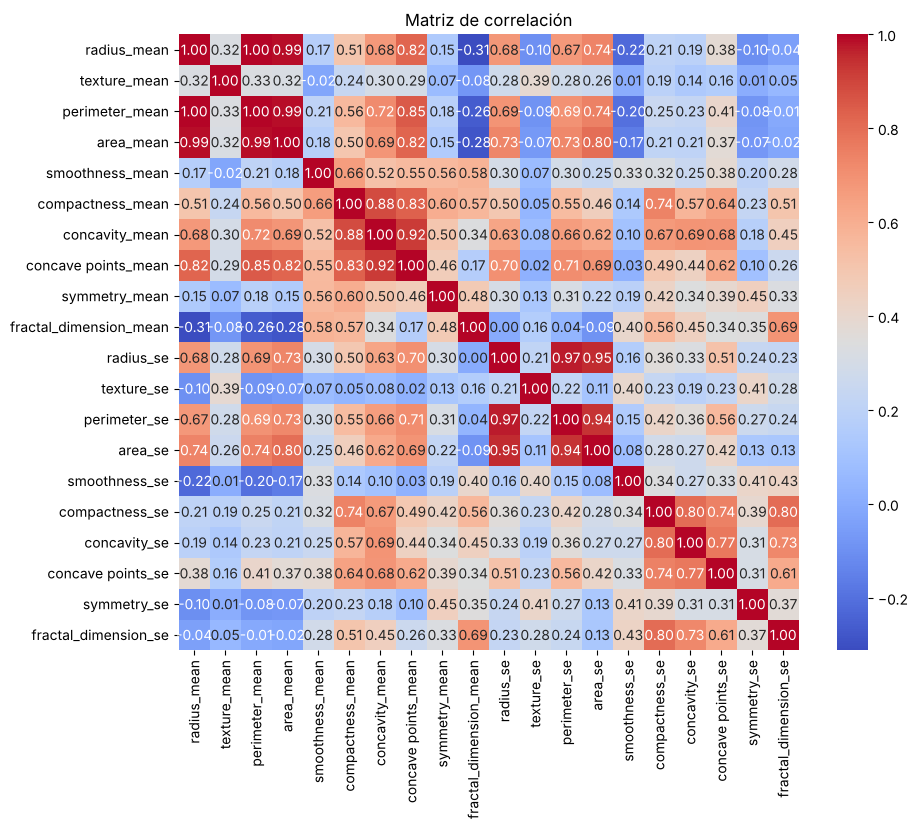

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(cancer_copy.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

**Resultado.** Tras eliminar las columnas `_worst` quedan 7 pares con |r| > 0.9. Al descartar `radius_mean`, `area_mean`, `concavity_mean`, `perimeter_se` y `area_se` quedan **15 predictores**, y ninguna correlación entre ellos supera 0.9. La más alta es `perimeter_mean` – `concave points_mean` (≈ 0.85), por lo que persiste multicolinealidad moderada, que se refleja en los coeficientes de la Sección 8.

Dos matices sobre el criterio: (1) las diferencias entre `radius`, `perimeter` y `area` son mínimas, así que elegir una u otra es prácticamente indiferente; (2) la correlación con el objetivo se calculó con **todo** el conjunto de datos, incluido el de prueba (ver Notas).

---

## 4. Partición de los datos y función de evaluación

**Objetivos**
- Separar los predictores `X` del objetivo `y` usando el dataframe original `cancer_df` (la eliminación de variables se integrará en el pipeline).
- Codificar `diagnosis` como 0 (benigno) y 1 (maligno).
- Dividir en entrenamiento y prueba (80:20) con `random_state=1`.
- Definir `evaluate_model(actual, predicted)`, que imprime recall, precisión y *accuracy*.

In [12]:
# Separación de variables
x = cancer_df.drop(columns=['diagnosis'])
y = cancer_df['diagnosis'].map({'M': 1, 'B': 0})

# Separar el conjunto de datos en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

# Evaluación del modelo
def evaluate_model(actual, predicted):
    print(f'Recall: {recall_score(actual, predicted)}')
    print(f'Precision: {precision_score(actual, predicted)}')
    print(f'Accuracy: {accuracy_score(actual, predicted)}')

---

## 5. Modelo 1: variables correlacionadas eliminadas (*Correlation_Clean*)

**Objetivos**
- Crear un transformador `preprocessing` con `ColumnTransformer` que elimine las columnas correlacionadas, con `remainder='passthrough'`.
- Entrenar un pipeline `preprocessing` + regresión logística y evaluarlo en el conjunto de prueba.
- Registrar las métricas en un dataframe de resultados.

In [13]:
# Columnas _worst + columnas redundantes a eliminar
worst_cols += ['radius_mean', 'area_mean', 'concavity_mean', 'perimeter_se', 'area_se']

# Transformador previo al modelo
preprocessing = ColumnTransformer([
    ('drop_columns', 'drop', worst_cols)
    ], remainder='passthrough')

# Pipeline para el modelo de regresión logística
logr_model = make_pipeline(preprocessing, LogisticRegression(max_iter=10000))
logr_model.fit(x_train, y_train)
y_pred = logr_model.predict(x_test)
evaluate_model(y_test, y_pred)

# Dataframe de resultados
resultados = pd.DataFrame(columns=['Modelo', 'Recall', 'Precision', 'Accuracy'])
resultados.loc[0] = ['Correlation_Clean', recall_score(y_test, y_pred), precision_score(y_test, y_pred), accuracy_score(y_test, y_pred)]
display(resultados)

Recall: 0.7619047619047619
Precision: 0.8888888888888888
Accuracy: 0.8771929824561403


,Modelo,Recall,Precision,Accuracy
0,Correlation_Clean,0.761905,0.888889,0.877193


**Resultado.** Recall 0.762, precisión 0.889, *accuracy* 0.877. Es el peor de los tres modelos, pero **no es una línea base justa**: las variables no están escaladas (`perimeter_mean` ≈ 92 frente a `smoothness_mean` ≈ 0.1), y la regularización L2 de `LogisticRegression` más el optimizador dependen de la escala. Los modelos siguientes mejoran en buena medida por ese motivo (ver Sección 7).

---

## 6. Modelo 2: escalado estándar + PCA (*Standard_PCA*)

**Objetivos**
- Construir un pipeline con escalado estándar, PCA (número mínimo de componentes que expliquen ≥ 90 % de la varianza) y regresión logística, como alternativa para reducir la multicolinealidad.
- Entrenar, evaluar y añadir las métricas al dataframe de resultados.
- Reportar cuántos componentes principales se emplearon.

In [14]:
logr_model_pca = make_pipeline(preprocessing, StandardScaler(), PCA(n_components=0.90), LogisticRegression(max_iter=10000))
logr_model_pca.fit(x_train, y_train)
y_pred = logr_model_pca.predict(x_test)
evaluate_model(y_test, y_pred)

resultados.loc[1] = ['Standard_PCA', recall_score(y_test, y_pred), precision_score(y_test, y_pred), accuracy_score(y_test, y_pred)]
display(resultados)

Recall: 0.9047619047619048
Precision: 0.9743589743589743
Accuracy: 0.956140350877193


,Modelo,Recall,Precision,Accuracy
0,Correlation_Clean,0.761905,0.888889,0.877193
1,Standard_PCA,0.904762,0.974359,0.956140


In [15]:
# Número de componentes principales retenidos (>= 90 % de la varianza)
pca_step = logr_model_pca.named_steps['pca']
print(f'Componentes principales utilizados: {pca_step.n_components_}')
print(f'Varianza explicada acumulada: {pca_step.explained_variance_ratio_.sum():.1%}')

Componentes principales utilizados: 7
Varianza explicada acumulada: 90.5%


**Resultado.** PCA retuvo **7 componentes** (de 15 variables) y alcanzó recall 0.905, precisión 0.974 y *accuracy* 0.956. La mejora frente al Modelo 1 combina el escalado y la reducción de multicolinealidad; los componentes, además, son combinaciones lineales difíciles de interpretar clínicamente.

---

## 7. Modelo 3: transformación Yeo-Johnson (*Correlation_Yeo*)

**Objetivos**
- Dado que casi todas las variables son asimétricas (14 de los 15 predictores con asimetría > 0.5), construir un pipeline con `preprocessing`, una transformación Yeo-Johnson y regresión logística.
- Entrenar, evaluar y añadir las métricas al dataframe de resultados.
- Comparar con un control que use solo `StandardScaler`, para aislar el efecto de la transformación.

In [16]:
logr_model_yeo = make_pipeline(preprocessing, PowerTransformer(method="yeo-johnson"), LogisticRegression(max_iter=10000))
logr_model_yeo.fit(x_train, y_train)
y_pred_yeo = logr_model_yeo.predict(x_test)
evaluate_model(y_test, y_pred_yeo)

resultados.loc[2] = ['Correlation_Yeo', recall_score(y_test, y_pred_yeo), precision_score(y_test, y_pred_yeo), accuracy_score(y_test, y_pred_yeo)]
display(resultados)

Recall: 0.9523809523809523
Precision: 1.0
Accuracy: 0.9824561403508771


,Modelo,Recall,Precision,Accuracy
0,Correlation_Clean,0.761905,0.888889,0.877193
1,Standard_PCA,0.904762,0.974359,0.956140
2,Correlation_Yeo,0.952381,1.000000,0.982456


**Resultado.** Recall 0.952, precisión 1.000, *accuracy* 0.982: el mejor de los tres modelos.

In [17]:
# Análisis adicional: ¿cuánto de la mejora proviene solo del escalamiento?
logr_model_std = make_pipeline(preprocessing, StandardScaler(), LogisticRegression(max_iter=10000))
logr_model_std.fit(x_train, y_train)
y_pred_std = logr_model_std.predict(x_test)
evaluate_model(y_test, y_pred_std)

Recall: 0.9285714285714286
Precision: 0.975
Accuracy: 0.9649122807017544


**Control: ¿cuánto aporta realmente Yeo-Johnson?** Con solo `StandardScaler`, el modelo logra recall 0.929, precisión 0.975 y *accuracy* 0.965. Frente a ese control, Yeo-Johnson añade un verdadero positivo y elimina un falso positivo, es decir, **una diferencia de 1–2 pacientes sobre 114**, dentro del ruido de un conjunto de prueba tan pequeño. La conclusión sólida es que **el salto de 0.76 a ~0.93–0.95 de recall se debe sobre todo al escalado**, no a la transformación. Yeo-Johnson (con `standardize=True`) escala y reduce el peso de las colas, pero la regresión logística no exige normalidad de las variables.

---

## 8. Coeficientes del modelo

**Objetivos**
- Obtener los nombres de los predictores empleados por el modelo Yeo-Johnson. ¿Cuántos son?
- Identificar los 10 más influyentes según la magnitud de sus coeficientes.
- Graficarlos en un diagrama de barras horizontal, respetando el signo.

In [18]:
# Nombres de los predictores empleados
columnames = logr_model_yeo.named_steps['columntransformer'].get_feature_names_out()
yeo_names = logr_model_yeo.named_steps['powertransformer'].get_feature_names_out(columnames)
coefs = logr_model_yeo.named_steps['logisticregression'].coef_[0]
print('Número de predictores:', len(yeo_names))
print(yeo_names)

Número de predictores: 15
['remainder__texture_mean' 'remainder__perimeter_mean'
 'remainder__smoothness_mean' 'remainder__compactness_mean'
 'remainder__concave points_mean' 'remainder__symmetry_mean'
 'remainder__fractal_dimension_mean' 'remainder__radius_se'
 'remainder__texture_se' 'remainder__smoothness_se'
 'remainder__compactness_se' 'remainder__concavity_se'
 'remainder__concave points_se' 'remainder__symmetry_se'
 'remainder__fractal_dimension_se']


In [19]:
coef_df = pd.DataFrame({'Nombre': yeo_names, 'Coeficientes': coefs})
coef_df['Coef_abs'] = coef_df['Coeficientes'].abs()
coef_df.sort_values('Coef_abs', ascending=False, inplace=True)
coef_df.head(10)

,Nombre,Coeficientes,Coef_abs
4,remainder__concave points_mean,2.437213,2.437213
0,remainder__texture_mean,1.901142,1.901142
1,remainder__perimeter_mean,1.444827,1.444827
7,remainder__radius_se,1.325590,1.325590
11,remainder__concavity_se,0.999924,0.999924
5,remainder__symmetry_mean,0.783934,0.783934
13,remainder__symmetry_se,-0.723084,0.723084
10,remainder__compactness_se,-0.706822,0.706822
3,remainder__compactness_mean,0.582670,0.582670
12,remainder__concave points_se,-0.564883,0.564883


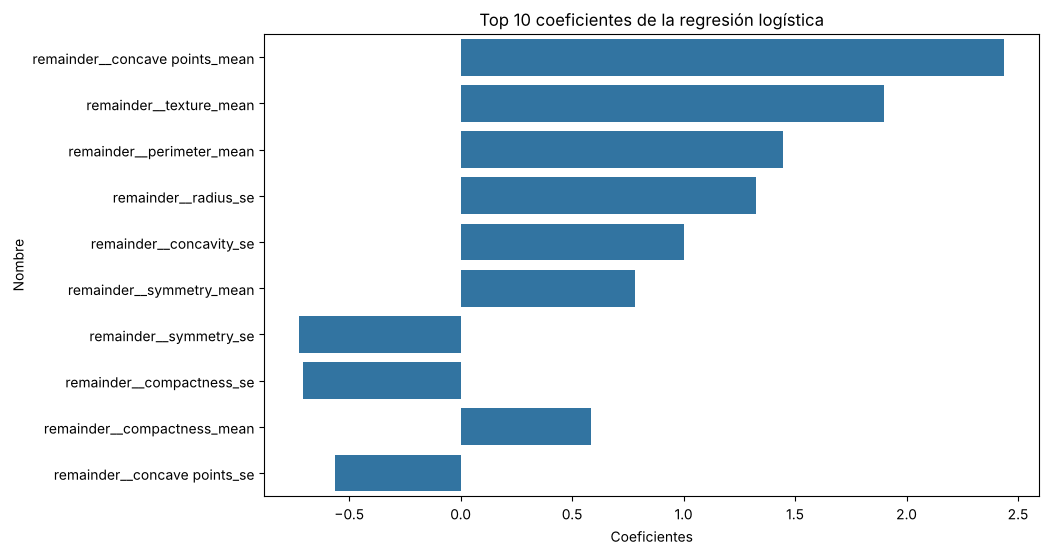

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficientes', y='Nombre', data=coef_df.head(10))
plt.title('Top 10 coeficientes de la regresión logística')
plt.show()

**Resultado.** El modelo usa **15 predictores**. Los coeficientes son comparables entre sí porque `PowerTransformer` estandariza cada variable (media 0, desviación 1); cada uno indica el cambio en el log-odds de malignidad por una desviación estándar. Los mayores son `concave points_mean` (+2.44), `texture_mean` (+1.90), `perimeter_mean` (+1.44), `radius_se` (+1.33) y `concavity_se` (+1.00).

Interpretación con cautela:
- `texture_mean` es el segundo predictor pese a discriminar menos por sí sola: aporta información que no está en las variables de tamaño (Sección 2.2).
- Los coeficientes negativos de `symmetry_se`, `compactness_se` y `concave points_se` contrastan con el signo positivo de sus equivalentes `_mean`. Es probable que sea un efecto de la colinealidad dentro del grupo `_se` (p. ej. `compactness_se` – `concavity_se` ≈ 0.80), no una relación causal.
- Los coeficientes están sesgados hacia cero por la regularización L2 (`C=1` por defecto).

---

## 9. Evaluación del mejor modelo

**Objetivos**
- Mostrar el dataframe de resultados.
- Dibujar la matriz de confusión del mejor modelo e interpretar cada valor.
- Dibujar la curva ROC y describir qué indica sobre la capacidad de distinguir entre clases.

### 9.1 Comparación de modelos y matriz de confusión

In [21]:
resultados

,Modelo,Recall,Precision,Accuracy
0,Correlation_Clean,0.761905,0.888889,0.877193
1,Standard_PCA,0.904762,0.974359,0.956140
2,Correlation_Yeo,0.952381,1.000000,0.982456


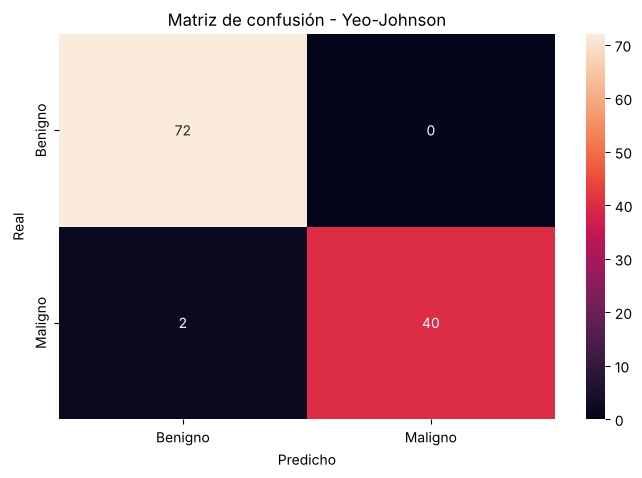

In [22]:
cm = confusion_matrix(y_test, y_pred_yeo)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Benigno', 'Maligno'], yticklabels=['Benigno', 'Maligno'])
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.title('Matriz de confusión - Yeo-Johnson')
plt.show()

**Resultado.** Matriz de confusión del modelo *Correlation_Yeo* (conjunto de prueba, 114 pacientes):

| | Predicho benigno | Predicho maligno |
|---|---|---|
| **Real benigno** | VN = 72 | FP = 0 |
| **Real maligno** | FN = 2 | VP = 40 |

- **VN (72):** benignos correctamente identificados. **VP (40):** malignos correctamente identificados.
- **FP (0):** ninguna falsa alarma. **FN (2):** dos tumores malignos clasificados como benignos.
- Los **falsos negativos** son el error más grave: un cáncer real que se interpreta como benigno retrasa el diagnóstico y el tratamiento. Por eso el recall (40/42 = 0.952) es la métrica principal, aunque no debe evaluarse sola.

### 9.2 Curva ROC

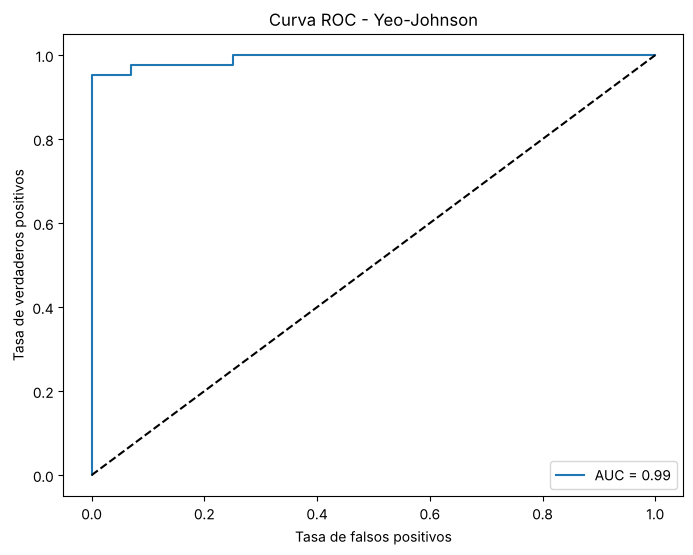

In [23]:
y_prob = logr_model_yeo.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC - Yeo-Johnson')
plt.legend()
plt.show()

**Resultado.** AUC = 0.99: la curva se acerca a la esquina superior izquierda y queda muy por encima de la diagonal (clasificador aleatorio), es decir, el modelo ordena casi siempre a los malignos por encima de los benignos. Es un valor muy alto, pero está estimado con 114 pacientes y con el modelo elegido tras ver el conjunto de prueba (ver Notas), por lo que probablemente sea algo optimista.

---

## 10. Distribución de probabilidades y umbral de decisión

**Objetivos**
- Graficar la distribución de la probabilidad predicha de la clase positiva (maligno) con histogramas superpuestos, por clase real.
- ¿Cuál es el umbral por defecto de scikit-learn? ¿Qué métrica es más importante en diagnóstico médico? ¿Cómo y por qué cambiar el umbral?

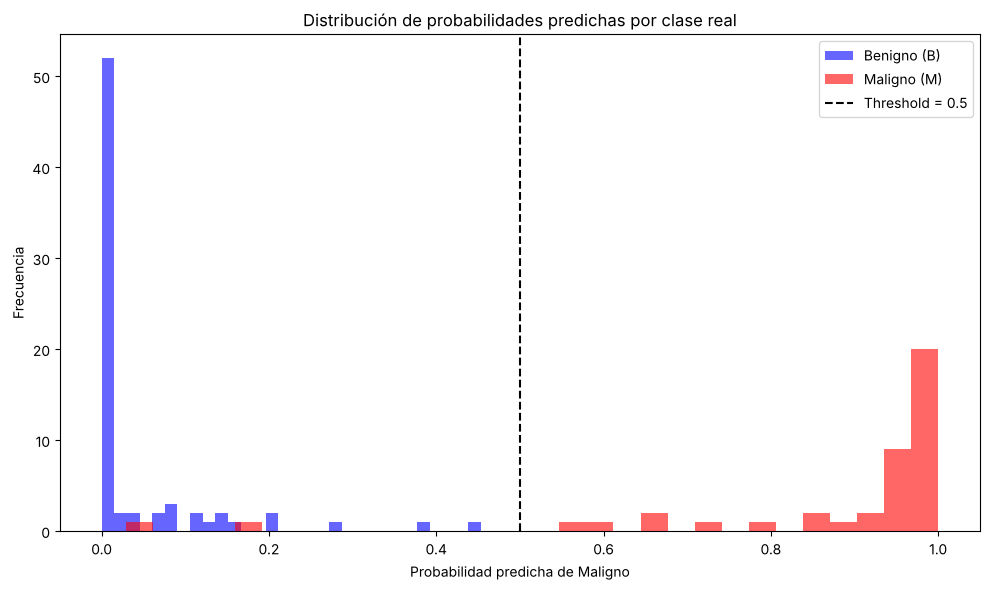

In [24]:
plt.figure(figsize=(10, 6))

# Separar probabilidades por clase real
proba_benigno = y_prob[y_test == 0]
proba_maligno = y_prob[y_test == 1]

plt.hist(proba_benigno, bins=30, alpha=0.6, label='Benigno (B)', color='blue')
plt.hist(proba_maligno, bins=30, alpha=0.6, label='Maligno (M)', color='red')
plt.axvline(0.5, color='black', linestyle='--', label='Threshold = 0.5')
plt.xlabel('Probabilidad predicha de Maligno')
plt.ylabel('Frecuencia')
plt.title('Distribución de probabilidades predichas por clase real')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Efecto de distintos umbrales sobre la matriz de confusión (conjunto de prueba)
filas = []
for umbral in [0.5, 0.3, 0.2, 0.1]:
    pred_umbral = (y_prob >= umbral).astype(int)
    vn, fp, fn, vp = confusion_matrix(y_test, pred_umbral).ravel()
    filas.append({'Umbral': umbral, 'VP': vp, 'FP': fp, 'FN': fn, 'VN': vn,
                  'Recall': recall_score(y_test, pred_umbral),
                  'Precision': precision_score(y_test, pred_umbral)})
pd.DataFrame(filas)

,Umbral,VP,FP,FN,VN,Recall,Precision
0,0.5,40,0,2,72,0.952381,1.000000
1,0.3,40,2,2,70,0.952381,0.952381
2,0.2,40,5,2,67,0.952381,0.888889
3,0.1,41,11,1,61,0.976190,0.788462


**Resultado.**
- **Umbral por defecto:** 0.5 (`predict` asigna «maligno» si la probabilidad es ≥ 0.5).
- **Métrica prioritaria:** el recall, porque un falso negativo (cáncer no detectado) es mucho más costoso que un falso positivo (pruebas adicionales). Aun así, un recall alto a costa de precisión muy baja saturaría el sistema de falsas alarmas, así que se vigilan ambas.
- **Cambio del umbral:** bajarlo aumenta el recall a cambio de más falsos positivos. La tabla anterior muestra, sin embargo, que **aquí no ayuda de forma razonable**: los dos falsos negativos tienen probabilidades de ≈ 0.03 y ≈ 0.17, muy por debajo de 0.5. Con umbral 0.3 o 0.2 no se recupera ninguno y se añaden 2 y 5 falsos positivos; solo con 0.1 se recupera uno (recall 0.976) a costa de 11 falsos positivos. El caso con p ≈ 0.03 no se recupera con ningún umbral razonable: el modelo está «seguro» de que es benigno, lo que sugiere un caso atípico o una etiqueta dudosa que conviene revisar.
- Los tumores malignos con probabilidad entre 0.5 y 0.6 que se ven en el gráfico están **bien clasificados**; son los más cercanos al umbral, no errores.
- El umbral debe elegirse con datos de validación y una razón de costos explícita (costo de FN frente a FP), no con el conjunto de prueba.

---

## 11. Notas y siguientes pasos

- **Uso clínico.** Es un ejercicio académico con un conjunto de datos pequeño de una sola fuente; no hay validación externa y el modelo no debe usarse para decisiones clínicas.
- **Fuga de datos en la selección de variables.** La correlación con el objetivo (Sección 3) se calculó con todo el conjunto, incluidos los registros de prueba. El efecto aquí es pequeño, pero lo correcto es calcularla solo con el entrenamiento o integrar la selección en el pipeline. El escalado, PCA y Yeo-Johnson sí están dentro del pipeline, por lo que no filtran información de la prueba.
- **Conjunto de prueba pequeño.** Con 42 casos malignos, cada falso negativo mueve el recall 2.4 puntos; el recall de 40/42 tiene un intervalo de confianza del 95 % (Wilson) de aproximadamente 84 %–99 %. Las diferencias de 1–2 pacientes entre modelos no son significativas.
- **Validación.** Se usó una sola partición, sin estratificar. Validación cruzada estratificada repetida (`StratifiedKFold`, `stratify=y`) daría una estimación más estable e intervalos de incertidumbre.
- **Selección del mejor modelo sobre la prueba.** Elegir el «mejor» modelo y reportar sus métricas con los mismos datos produce una estimación optimista. Lo correcto es seleccionar con validación cruzada y reservar la prueba para una evaluación final.
- **Alternativas de modelado.** Ajustar `C` (regularización), probar L1/L2 con las 30 variables en lugar de descartar 15 a mano, y comparar con modelos no lineales (p. ej. bosques aleatorios) antes de concluir que la regresión logística es suficiente.
- **Umbral y calibración.** Elegir el umbral con datos de validación y costos explícitos; revisar la calibración de las probabilidades si se van a usar como riesgo.

---

## Declaración de uso de IA

- Anthropic. (2026). *Claude* (claude-sonnet-5-5) [Modelo de lenguaje grande]. Utilizado para reestructurar y dar formato a la documentación del notebook, corregir errores del código y de los textos, y añadir los análisis complementarios (número de componentes de PCA, control con `StandardScaler`, tabla de umbrales). https://claude.ai